# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [1]:
import sys, os
import openpyxl as _xl
from dotenv import load_dotenv
load_dotenv()
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
from optimizer import run_optimization
print('Setup OK')

c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


## 1. Model and technologies

In [2]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

  Copied fuel-financial-inputs.xlsx from template
  Copied carbon-credits.xlsx from template
Files to recreate from templates:
  design-capital-CleanStep.xlsx: does not exist
  technoeconomic-inputs-CleanStep.xlsx: does not exist
  financial-statements-CleanStep.xlsx: does not exist
  capex-fuels-CleanStep.xlsx: does not exist
  design-capital-CleanStep.xlsx
  technoeconomic-inputs-CleanStep.xlsx
  financial-statements-CleanStep.xlsx
  capex-fuels-CleanStep.xlsx
Model CleanStep ready.


## 2. Country-level inputs

In [3]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [4]:
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 2101.6, 2235.1, 2355.9, 2518.5, 2659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


### Capital Structure Optimisation
Optuna searches for the combination of equity/grants/debt/costs that minimises total debt (or long-term subsidies) across the planning horizon. `SEARCH_RANGES` defines the search space and `OBJECTIVE` controls what is minimised.

In [5]:
SEARCH_RANGES = {
    'pct_equity':          (0.10, 0.40), 
    'pct_grants':          (0.10, 0.30),
    'cost_equity':         (0.08, 0.20),
    'cost_debt':           (0.04, 0.12),
    'years_realisation':   (2, 5),
    'grace_period':        (1, 3),
    'amortization_period': (5, 30),
}
OBJECTIVE = 'debt'   # 'debt'/'lts
N_TRIALS  = 100

CAPITAL_STRUCTURE = {}
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"Optimising {tech}...")
    CAPITAL_STRUCTURE[tech] = run_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        fuel_fin=FUEL_FIN,
        tariffs=TARIFFS,
        fuel_key='Electricity',
        search_ranges=SEARCH_RANGES,
        objective=OBJECTIVE,
        n_trials=N_TRIALS,
    )
    print(f"  → {CAPITAL_STRUCTURE[tech]}")

print("Optimising LPG...")
CAPITAL_STRUCTURE['LPG'] = run_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    fuel_fin=FUEL_FIN,
    tariffs=TARIFFS,
    fuel_key='LPG',
    search_ranges=SEARCH_RANGES,
    objective=OBJECTIVE,
    n_trials=N_TRIALS,
)
print(f"  → {CAPITAL_STRUCTURE['LPG']}")

for sheet, cs in CAPITAL_STRUCTURE.items():
    print(f"\n{sheet}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  CAPEX  " + "".join(f"{round(v,1):>10}" for v in cs.get('CAPEX_SCHEDULE', [])))
    print("  DEBT   " + "".join(f"{round(v,1):>10}" for v in cs.get('DEBT_INCREASE',  [])))
    print("  LTS    " + "".join(f"{round(v,1):>10}" for v in cs.get('LT_SUBSIDY_SCHEDULE', [])))

Optimising Electricity & E-Cooking...
K1=0.34, K2=0.069
Trial 0: total debt=9e+02, debt=[0, 0, 0, 919.6024945725569, 1.4246754493527829e-11, 0, 0, 0, 0, 0, 0, 0], capex=[486.60791049577796, 173.3631037965581, 201.39007151757946, 1477.490588773278, 322.6654677517338, 272.14704579990956, 175.40677726975946, 196.2651232037607, 219.2407374138154, 267.0199357767994, 324.8737028348442, 414.52953536609743], lt_subsidies=[-6.127215248523157e-14, 0, -5.773159728050814e-13, 56.950532370531576, 55.979775527443046, 49.18819701040755, 34.585411677617245, 20.473797653011843, 6.429694407300432, 0, 0, 0]
Trial 1: total debt=8e+02, debt=[0, 0, 0, 767.0252368794454, 0, 0, 0, 0, 0, 0, 0, 0], capex=[265.575971725, 166.01969072783925, 193.45271093534805, 1286.6848510061664, 231.21288229290457, 227.79891991629506, 257.348593577067, 291.8137137616799, 330.5186538240331, 373.9409440850312, 422.6671745792548, 483.9658935693814], lt_subsidies=[0, -1.4557383836510243e-13, 0, 69.35629612318252, 67.06703511709095,

## 4. Write inputs

In [6]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.carbon_credits_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.reset_circular_rows(sheet)
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  carbon-credits.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  carbon-credits.xlsx / Carbon Credits -> Liquidity
  carbon-credits.xlsx / Carbon Credits -> Price per TON
  carbon-credits.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  Reset accumulator rows for Electricity & E-Cooking in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx /

## 5. Run engine

In [7]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence()
print('Done.')

Running engine...
  Converged in 35 iterations.
Done.


In [8]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::LPG::Annual Cost of Service,FS::LPG::Check,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Check,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,0.000000,0.000000,0.000000,114.4079,12.000000,0.000000,0.000000,0.000000,38.624704,...,1137.784857,-2.828287e+01,0.895726,-42.104274,0.000000,3892.408534,-1.122190e+01,-35.749315,-3418.449315,NaN
1,2,1797.118521,700.876223,539.135556,114.4079,16.298356,1449.260986,449.270906,420.285686,38.624704,...,1143.168685,-1.189297e+02,23.176533,-19.823467,0.000000,4596.781518,-6.833953e+03,2379.639477,-1003.060523,1.008361e+04
2,3,1004.103361,391.600311,301.231008,114.4079,15.869505,742.111818,230.054664,215.212427,38.624704,...,1147.088097,-9.510335e+01,28.560361,-14.439639,100.308809,5023.391261,-3.721231e+03,2380.612819,-1002.087181,4.459646e+03
3,4,1000.259255,390.101109,300.077777,114.4079,15.866146,741.462923,229.853506,215.024248,38.624704,...,1150.813667,-7.304356e+01,32.479773,-10.520227,332.064231,5438.715628,-3.355241e+03,2481.967070,-900.732930,6.692353e+02
4,5,936.319217,365.164495,280.895765,114.4079,15.807188,649.467080,201.334795,188.345453,38.624704,...,1154.459922,-6.121873e+01,36.205343,-6.794657,612.269082,5796.962007,-2.828230e+03,2714.840034,-667.859966,7.753127e+02
5,6,834.471172,325.443757,250.341352,114.4079,15.699472,549.933328,170.479332,159.480665,38.624704,...,1158.027150,-4.907603e+01,39.851598,-3.148402,880.181232,6100.180045,-2.372431e+03,2996.234526,-386.465474,8.154680e+02
6,7,791.101328,308.529518,237.330398,114.4079,15.647461,507.769548,157.408560,147.253169,38.624704,...,1161.405896,-4.228925e+01,43.418826,0.418826,1149.072704,6368.308165,-2.085789e+03,3265.408416,-117.291584,4.628923e+02
7,8,795.310416,310.171062,238.593125,114.4079,15.652690,513.763466,159.266674,148.991405,38.624704,...,1164.388303,-3.358262e+01,46.797572,3.797572,1389.861128,6609.211254,-1.839919e+03,3535.597678,152.897678,2.824363e+02
8,9,797.342779,310.963684,239.202834,114.4079,15.655200,516.871517,160.230170,149.892740,38.624704,...,1166.810878,-2.022829e+01,49.779979,6.779979,1585.084601,6804.493342,-1.439688e+03,3777.683893,394.983893,4.452053e+02
9,10,797.138441,310.883992,239.141532,114.4079,15.654948,516.404648,160.085441,149.757348,38.624704,...,1168.623333,-4.955457e+00,52.202555,9.202555,1732.036849,6951.436821,-8.644980e+02,3973.556261,590.856261,6.566143e+02


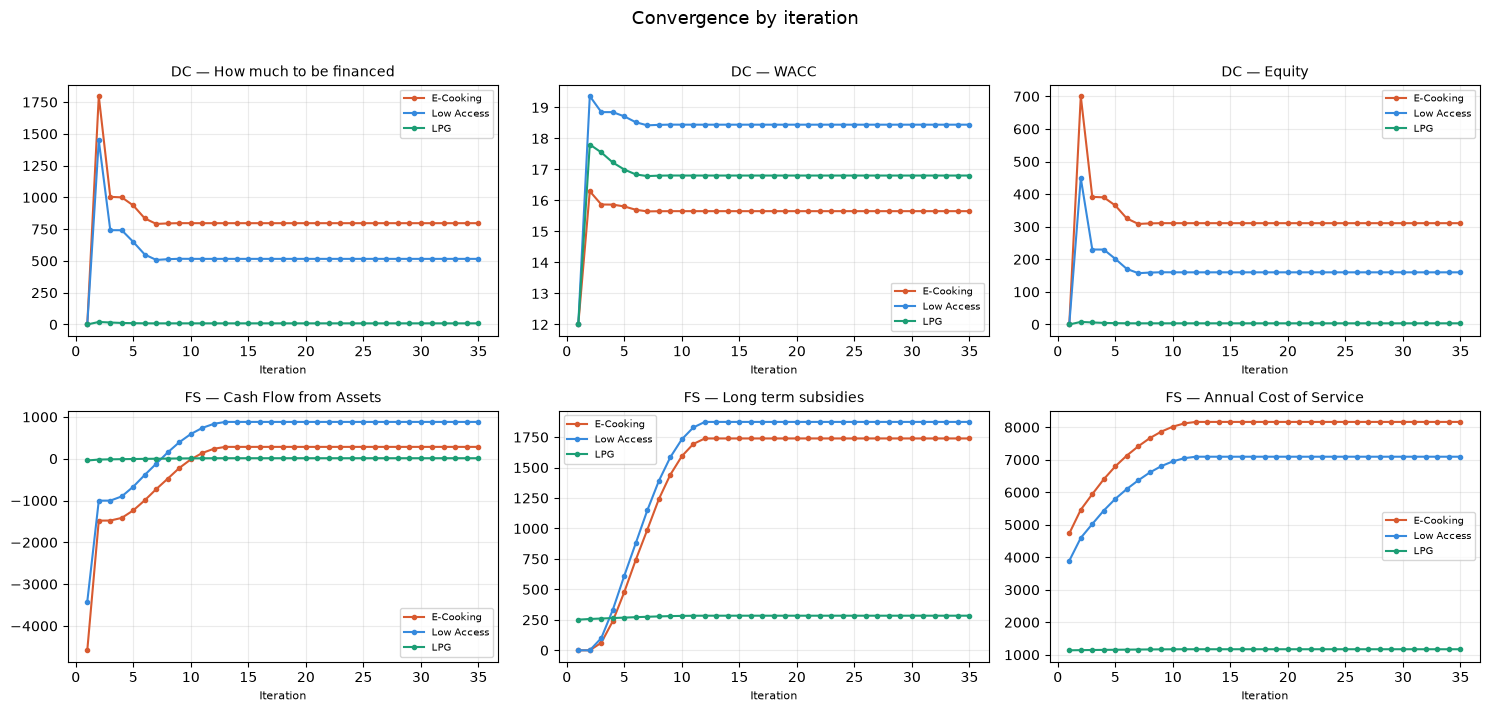

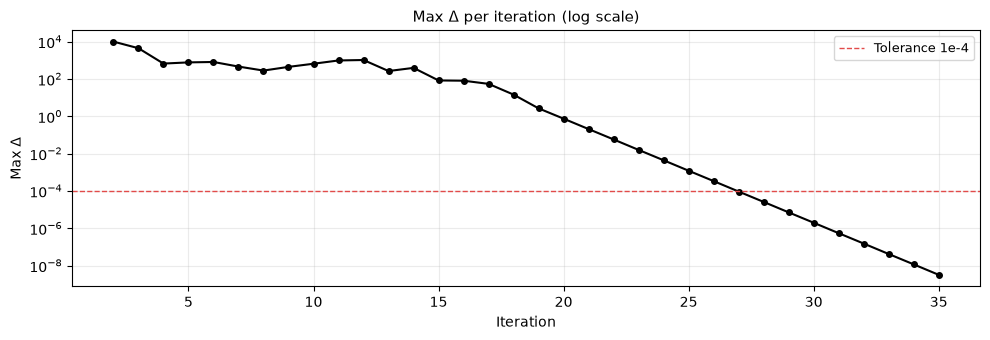

In [9]:
pio.plot_convergence(df_conv)

### Debt requirements

The platform calculates the annual debt needed to cover negative cash positions. 
Review below and optionally inject it back into the model before re-running.

In [10]:
print("=== REQUIRED DEBT PER TECHNOLOGY ===")
REQUIRED_DEBT = {}
for SHEET in pio.get_expanded_sheets():
    req = pio.read_required_debt(SHEET)
    REQUIRED_DEBT[SHEET] = req
    print(f"\n{SHEET}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  " + "".join(f"{round(v,1):>10}" for v in req))

=== REQUIRED DEBT PER TECHNOLOGY ===

Electricity & E-Cooking
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Electricity (Low access)
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       4.6      41.3      19.5       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

LPG
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [11]:
USE_REQUIRED_DEBT = False   # True = automatically inject platform-calculated debt
DEBT_OVERRIDE     = None   # Or: {'Electricity & E-Cooking': [0, 34, 96, 0, ...]}
MAX_DEBT_ITER     = 8 
DEBT_TOL          = 0.5

accumulated = {
    sheet: list(CAPITAL_STRUCTURE[sheet].get('DEBT_INCREASE', [0]*len(YEARS)))
    for sheet in pio.get_expanded_sheets()
}

if DEBT_OVERRIDE:
    for sheet, vals in DEBT_OVERRIDE.items():
        accumulated[sheet] = list(vals)

if USE_REQUIRED_DEBT or DEBT_OVERRIDE:
    print("=== DEBT CONVERGENCE LOOP ===")
    df_conv2 = None
    for debt_iter in range(MAX_DEBT_ITER):
        total_needed = 0
        for sheet in pio.get_expanded_sheets():
            req = pio.read_required_debt(sheet)
            total_needed += sum(req)
            for t, v in enumerate(req):
                if t < len(accumulated[sheet]):
                    accumulated[sheet][t] += v

        print(f"  Iter {debt_iter+1}: remaining debt needed = {total_needed:.2f} M$")

        if total_needed < DEBT_TOL:
            print(f"  Converged in {debt_iter+1} iteration(s).")
            break

        for sheet, vals in accumulated.items():
            pio.write_design_debt_list(sheet, vals)
            CAPITAL_STRUCTURE[sheet]['DEBT_INCREASE'] = vals

        df_conv2 = pio.run_engine_until_convergence()
    else:
        print(f"  Warning: did not converge after {MAX_DEBT_ITER} iterations.")

    if df_conv2 is not None:
        display(df_conv2)

    print("\n=== FINAL INJECTED DEBT PER TECHNOLOGY ===")
    for sheet, vals in accumulated.items():
        print(f"\n{sheet}")
        print("  " + "".join(f"{y:>10}" for y in YEARS))
        print("  " + "".join(f"{round(v,1):>10}" for v in vals))
else:
    print("No debt injection applied.")

No debt injection applied.


## 6. Outputs

In [12]:
col_w = 10
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))
    check_vals = out.get('Check', [0]*len(YEARS))
    if any(abs(v) > 1 for v in check_vals):
        print(f"\n  ⚠  Balance sheet check FAILED: {[round(v,1) for v in check_vals]}")
    else:
        print(f"\n  ✓  Balance sheet OK")


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0         0      23.7      71.6     106.0     138.4     176.0     206.6     231.4     254.4     276.2     254.8
EBITDA                                  247.2     296.6     351.1     407.7     471.5     424.9     492.0     570.3     645.2     716.7     785.1     839.9
Net Income                              196.5     230.5     268.0     309.0     351.4     288.5     339.6     396.8     450.2     500.6     548.5     577.1
Annual Cost of Service                  228.0     304.3     395.4     471.9     556.4     638.0     723.9     814.5     896.3     974.5    1049.5    1112.2
Check                                

In [13]:
# === COMPARISON: PYOMO vs PLATFORM ===
col_w = 9

k1_annual = [cs['TARIFF_INCOME'][t] / cs['CAPEX_SCHEDULE'][t] 
             if cs['CAPEX_SCHEDULE'][t] != 0 else 0 
             for t in range(len(YEARS))]
print("  K1 anual: " + ''.join(f"{round(v,3):>9}" for v in k1_annual))

COMP_VARS = [
    ('Tariff Income',        'TARIFF_INCOME',        'Annual Cost of Service'),  # plataforma no tiene tariff directo, usamos ACoS como proxy
    ('Grants',               'GRANTS_PYOMO',         'GRANTS:- Realisation'),
    ('LT Subsidies',         'LT_SUBSIDY_SCHEDULE',  'Long term subsidies'),
    ('Revenues',             'REVENUES_PYOMO',        None),
    ('Costs',                'COSTS_PYOMO',           None),
    ('EBITDA',               'EBITDA_PYOMO',          'EBITDA'),
    ('ACoS',                 None,                    'Annual Cost of Service'),  # añadir ACoS plataforma
    ('Financial Expenses',   'FINANCIAL_EXP_PYOMO',   'Financial Expense'),
    ('CFA',                  'CFA_PYOMO',             'Cash Flow from Assets'),
    ('Debt Increase',        'DEBT_INCREASE',         'DEBT:+ Increase'),
    ('CAPEX (Pyomo)',        'CAPEX_SCHEDULE',         None),
    ('ACoS', 'ACOS_PYOMO', 'Annual Cost of Service'),
]

for sheet in pio.get_expanded_sheets():
    cs  = CAPITAL_STRUCTURE[sheet]
    out = pio.read_outputs(sheet)

    print(f"\n{'='*80}")
    print(f"  {sheet}  —  K1={cs['K1']:.3f}, K2={cs['K2']:.3f}")
    print(f"{'='*80}")

    # CAPEX real del technoeconomic (plataforma)
    if sheet == 'LPG':
        capex_real = TECHNO_LPG.get('CAPEX - Growth', [0]*len(YEARS))
    else:
        g  = TECHNO_ELEC[sheet].get('GRID',     {}).get('CAPEX - Growth', [0]*len(YEARS))
        og = TECHNO_ELEC[sheet].get('OFF-GRID', {}).get('CAPEX - Growth', [0]*len(YEARS))
        capex_real = [g[t]+og[t] for t in range(len(YEARS))]

    print("  CAPEX Platform: " + ''.join(f"{round(v,1):>9}" for v in capex_real))
    print("  CAPEX Pyomo:    " + ''.join(f"{round(v,1):>9}" for v in cs['CAPEX_SCHEDULE']))
    print()

    print(f"{'Variable':<25} {'Source':<10}" + ''.join(f"{y:>{col_w}}" for y in YEARS) + f"{'TOTAL':>{col_w}}")
    print('-'*80)

    for name, pyomo_key, platform_key in COMP_VARS:
        if pyomo_key and pyomo_key in cs:
            vals = cs[pyomo_key]
            tot  = round(sum(vals), 1)
            print(f"{name:<25} {'Pyomo':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if platform_key and platform_key in out:
            vals = out[platform_key]
            tot  = round(sum(vals), 1)
            print(f"{'':<25} {'Platform':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if pyomo_key or platform_key:
            print()

  K1 anual:     5.382   26.164   22.785   15.227   19.136   18.627    23.23   17.523   21.192   16.733   19.863    16.21

  Electricity & E-Cooking  —  K1=0.341, K2=0.069
  CAPEX Platform:     296.8    374.9    371.2    367.5    363.8    360.2    397.4    434.0    429.7    425.3    421.1    289.1
  CAPEX Pyomo:        254.7    180.0    210.6    411.9    329.2    270.5    304.2    358.7    422.7    499.2    588.8    700.6

Variable                  Source         2023     2024     2025     2026     2027     2028     2029     2030     2031     2032     2033     2034    TOTAL
--------------------------------------------------------------------------------
Tariff Income             Pyomo         288.0    317.0    349.0    372.9    415.0    455.6    500.3    551.0    608.9    675.7    753.2    878.0   6164.8
                          Platform      228.0    304.3    395.4    471.9    556.4    638.0    723.9    814.5    896.3    974.5   1049.5   1112.2   8164.8

Grants                    Pyom

## 7. Summary metrics

In [14]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue

    lts      = out.get('Long term subsidies',  [0]*len(YEARS))
    equity   = out.get('Equity - EoP',         [0]*len(YEARS))
    debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
    grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next(
        (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
        None
    )
    _wb.close()

    total_lts    = round(sum(lts), 1)
    total_grants = round(sum(abs(v) for v in grants), 1)
    peak_equity  = round(max(equity), 1)
    peak_debt    = round(max(abs(v) for v in debt_eop), 1)

    print(f"\n{SHEET}")
    print(f"  WACC:               {wacc:.2f}%")
    print(f"  Total LTS:          {total_lts} M$")
    print(f"  Total grants:       {total_grants} M$")
    print(f"  Peak equity (EoP):  {peak_equity} M$")
    print(f"  Peak debt (EoP):    {peak_debt} M$")


Electricity & E-Cooking
  WACC:               15.65%
  Total LTS:          1739.0 M$
  Total grants:       532.3 M$
  Peak equity (EoP):  3821.8 M$
  Peak debt (EoP):    114.4 M$

Electricity (Low access)
  WACC:               18.44%
  Total LTS:          1874.9 M$
  Total grants:       414.7 M$
  Peak equity (EoP):  2819.1 M$
  Peak debt (EoP):    38.6 M$

LPG
  WACC:               16.80%
  Total LTS:          284.1 M$
  Total grants:       6.5 M$
  Peak equity (EoP):  23.3 M$
  Peak debt (EoP):    1.6 M$


## 8. AI Layer — RL Optimisation + LLM

In [15]:
from rl_agent import run_rl_optimization, load_agent, save_agent, log_run
from llm_layer import explain_results

### 8.1 RL Optimisation

In [16]:
N_ROUNDS = 20
N_TRIALS_PER_ROUND = 5
 
RL_RESULTS = {}
RL_HISTORIES = {}
 
# NEW: load the agent trained in the previous execution, if any
shared_agent, shared_optimizer, loaded = load_agent()
print(f"Loaded previously-trained agent: {loaded}")
 
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"\n=== RL: {tech} ===")
    best, history, shared_agent, shared_optimizer = run_rl_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        initial_ranges=SEARCH_RANGES,
        fuel_fin=FUEL_FIN,
        fuel_key='Electricity',
        objective=OBJECTIVE,
        n_rounds=N_ROUNDS,
        n_trials_per_round=N_TRIALS_PER_ROUND,
        tariffs=TARIFFS,
        agent=shared_agent,
        optimizer_=shared_optimizer,
    )
    RL_RESULTS[tech] = best
    RL_HISTORIES[tech] = history
 
print("\n=== RL: LPG ===")
best, history, shared_agent, shared_optimizer = run_rl_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    initial_ranges=SEARCH_RANGES,
    fuel_fin=FUEL_FIN,
    fuel_key='LPG',
    objective=OBJECTIVE,
    n_rounds=N_ROUNDS,
    n_trials_per_round=N_TRIALS_PER_ROUND,
    tariffs=TARIFFS,
    agent=shared_agent,
    optimizer_=shared_optimizer,
)
RL_RESULTS['LPG'] = best
RL_HISTORIES['LPG'] = history

save_agent(shared_agent, shared_optimizer)
log_run(run_label="notebook_run", results=RL_RESULTS, histories=RL_HISTORIES)

Loaded previously-trained agent: True

=== RL: Electricity & E-Cooking ===

── RL Round 1/20 ──
K1=0.34, K2=0.069
Trial 0: total debt=9e+02, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 925.5236868906071], capex=[588.6968966371098, 165.76372943618932, 191.75466605086459, 198.487682231047, 230.12244710310858, 214.8900190302136, 241.89803152545906, 271.42176995670036, 303.81014515780834, 339.459520630003, 378.8213627002337, 1405.873729541264], lt_subsidies=[0, 0, 0, 0, 0, 0, 0, 0, 7.81055206553017e-12, 1.180787826922902e-12, 0, 0]
Trial 1: total debt=9e+02, debt=[946.567977995989, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[1790.9867553907068, 240.65606272290321, 57.70817058049074, 67.79932553548531, 117.23369537232455, 166.7141508107562, 216.20670596193403, 265.90570041855665, 316.8206465553047, 370.0499210670179, 426.6593421410098, 494.2595234435098], lt_subsidies=[82.29330475476172, 85.9932049944242, 68.55393832186715, 67.53294427112709, 57.361367830453204, 48.47795474108736, 42.49603865013606

In [17]:
from pyomo.environ import SolverFactory, TerminationCondition, value
from pyomo_model import build_model, make_capex_data, make_k1_k2

tech_dict = TECHNO_ELEC['Electricity & E-Cooking']
n_periods = len(YEARS)
capex_total = make_capex_data(tech_dict, n_periods)
demand_base, K1, K2 = make_k1_k2(tech_dict, n_periods)
print(f"K1={K1:.4g}, K2={K2:.4g}, demand_base={demand_base:.4g}")

model = build_model(
    pct_debt=1 - 0.2,          # pct_equity
    pct_equity=0.2,
    pct_grants=0.13,
    cost_equity=0.16,
    cost_debt=0.08,
    grace_period=6,
    amortization_period=25,
    years_realisation=8,
    capex_total=capex_total,
    K1=K1, K2=K2,
    TAXRATE=TAX_RATE / 100,
    demand_base=demand_base,
    TARIFF={t: TARIFFS['Electricity'][t] if t < len(TARIFFS['Electricity']) else 0.0 for t in range(n_periods)},
    N_PERIODS=n_periods,
)

solver = SolverFactory('appsi_highs')
results = solver.solve(model)
print(results.solver.termination_condition)
print("total debt:", value(model.obj))

K1=0.3407, K2=0.06938, demand_base=1833
optimal
total debt: 770.5043389148782


### 8.2 Write RL results and re-run engine

In [18]:
for sheet, cs in RL_RESULTS.items():
    if cs is None:
        continue
    pio.reset_circular_rows(sheet)
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])

df_rl = pio.run_engine_until_convergence()
display(df_rl)

  Reset accumulator rows for Electricity & E-Cooking in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 30
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Equity = 14
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 2. Grants = 33
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Years realisation = 5
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Debt = 13
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Grace period = 1
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Amortization period = 21
  design-capital / Electricity & E-Cooking -> User-defined debt increase
  Reset accumulator rows for Electricity (Low access) in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 1. Equity = 45
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Cost of Equity = 14
  design-capital-CleanSt

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::LPG::Annual Cost of Service,FS::LPG::Check,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Check,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,797.054245,239.116274,263.027901,126.197738,13.654550,516.216127,232.297257,160.026999,62.886818,...,1138.046975,-8.114191e+01,55.583902,12.583902,0.000000,3926.330131,-4.843910e+03,4263.326472,880.626472,NaN
1,2,797.054245,239.116274,263.027901,126.197738,13.654550,516.216127,232.297257,160.026999,62.886818,...,1141.060560,-6.034998e+01,23.438651,-19.561349,0.000000,4287.928937,-3.812490e+03,2388.471659,-994.228341,1.874855e+03
2,3,998.337202,299.501161,329.451277,126.197738,13.703552,741.462923,333.658315,229.853506,62.886818,...,1144.483048,-9.289533e+01,26.452236,-16.547764,0.000000,4622.662595,-4.552431e+03,2380.989447,-1001.710553,7.399414e+02
3,4,999.619134,299.885740,329.874314,126.197738,13.703819,741.055320,333.474894,229.727149,62.886818,...,1147.515609,-7.854791e+01,29.874724,-13.125276,56.991094,4923.413050,-4.061493e+03,2382.456806,-1000.243194,5.041006e+02
4,5,986.567435,295.970231,325.567254,126.197738,13.701072,741.055320,333.474894,229.727149,62.886818,...,1150.446079,-6.377852e+01,32.907286,-10.092714,173.119263,5194.486860,-3.641144e+03,2441.032648,-941.667352,4.519485e+02
5,6,912.740622,273.822187,301.204405,126.197738,13.684521,690.373023,310.667860,214.015637,62.886818,...,1153.331859,-5.320101e+01,35.837755,-7.162245,320.300498,5431.699243,-3.049064e+03,2558.862953,-823.837047,5.920802e+02
6,7,873.398975,262.019692,288.221662,126.197738,13.674930,656.633881,295.485246,203.556503,62.886818,...,1156.042119,-4.510164e+01,38.723535,-4.276465,486.220402,5637.415332,-2.604537e+03,2707.863714,-674.836286,4.445271e+02
7,8,874.045708,262.213712,288.435084,126.197738,13.675093,657.090463,295.690708,203.698044,62.886818,...,1158.405022,-3.794658e+01,41.433795,-1.566205,640.826074,5813.012014,-2.289124e+03,2875.720532,-506.979468,3.154133e+02
8,9,874.420486,262.326146,288.558760,126.197738,13.675187,657.426630,295.841983,203.802255,62.886818,...,1160.328721,-2.663018e+01,43.796698,0.796698,783.846536,5956.034802,-1.917087e+03,3032.380507,-350.319493,3.720370e+02
9,10,874.414141,262.324242,288.556666,126.197738,13.675185,657.421891,295.839851,203.800786,62.886818,...,1161.772406,-1.272614e+01,45.720397,2.720397,892.732601,6064.920835,-1.395016e+03,3176.457468,-206.242532,5.220705e+02


### 8.3 LLM Explanation

In [19]:
from dotenv import load_dotenv
load_dotenv(override=True)

outputs_rl = {sheet: pio.read_outputs(sheet) for sheet in pio.get_expanded_sheets()}

pattern_results = {}
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    lts_sched  = cs.get('LT_SUBSIDY_SCHEDULE', [0]*len(YEARS))
    debt_sched = cs.get('DEBT_INCREASE',        [0]*len(YEARS))
    total_lts  = cs.get('TOTAL_LT_SUBSIDIES',   0)
    pattern_results[sheet] = {
        'subsidy_dependent': min(total_lts / 5000, 1.0),
        'fragile_structure': sum(1 for v in debt_sched if v > 0) / len(YEARS),
        'high_circularity':  0.0,
    }

explanation = explain_results(pattern_results, outputs_rl, RL_RESULTS, YEARS, country=COUNTRY, language='en', model='openai/gpt-oss-20b')
print(explanation)

The Mozambique CleanStep plan relies heavily on grants—grant shares are 33 %, 31 % and 24 % for electricity & e‑cooking, low‑access electricity and LPG respectively—while the equity load remains high (30 %–45 %). For electricity & e‑cooking the model had to raise only 126.2 M$ of debt (vs a 70 % target) but the peak debt of 126.2 M$ combined with a negative minimum cash balance of –35.2 M$ signals a liquidity risk that may require a longer grace period or additional cash‑buffer provisions. Low‑access electricity raised 62.9 M$ debt (target 55 %) and maintained a healthy 60.3 M$ minimum cash, reflecting a more conservative debt‑to‑equity mix, yet the cost of debt (12 %) is still close to the 14 % equity cost, so negotiating a lower interest rate or extending amortisation could improve the cost of capital. LPG’s debt exposure is minimal (only 2.4 M$ raised) and the project barely meets the 53 % target; however the negative min‑cash balance of –0.3 M$ and the higher equity cost (15 %) sug

### 8.4 Chat con el asesor IA

In [20]:
from dotenv import load_dotenv
load_dotenv(override=True)
from groq import Groq

capex_lines = []
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    capex = cs.get('CAPEX_SCHEDULE', [])
    tariff = cs.get('TARIFF_INCOME', [])
    capex_lines.append(
        f"- {sheet}: CAPEX total={round(sum(capex),1)} M$, "
        f"tariff income total={round(sum(tariff),1)} M$, "
        f"optimal equity={cs.get('PCT_EQUITY','?')}%, "
        f"optimal grants={cs.get('PCT_GRANTS','?')}%, "
        f"cost_debt={cs.get('COST_OF_DEBT','?')}%, "
        f"amortization={cs.get('AMORTIZATION','?')} years"
    )
context_data = "\n".join(capex_lines)

system_prompt = f"""You are a senior investment advisor specialising in clean energy
infrastructure financing in sub-Saharan Africa.
 
You are advising on the CleanStep scenario for {COUNTRY} ({YEARS[0]}-{YEARS[-1]}).
 
Key financial results from AI optimisation:
{explanation}
 
IMPORTANT -- financing-structure conventions used by this project's model
(follow these exactly, they differ from the generic textbook convention):
- Equity share and debt share are the two components of the capital
  structure and sum to 100% -- together they fully fund CAPEX.
- Grants are NOT part of the capital structure split, and do NOT fund
  additional CAPEX. They are a separate cash injection straight to
  treasury, covering other costs (e.g. working capital), which
  requires neither repayment (unlike debt) nor a return (unlike
  equity).
- WACC = cost_of_equity * equity_share + cost_of_debt * debt_share
  (grants have zero cost and are excluded from the WACC calculation).
- Debt repayment: no principal is repaid during the grace period.
  After the grace period, principal is repaid in equal instalments
  over the amortization period; interest each year accrues on the
  outstanding balance (debt raised so far minus principal already
  repaid) at the cost of debt.
When you propose a financing structure or a debt schedule, use these
exact conventions -- e.g. for 25% equity, debt share is 75%, not
whatever is left after also subtracting the grants percentage.
 
Your role is to propose financing structures, estimate viable debt
interest rate ranges for negotiation, and flag liquidity risks. Be
quantitative. Respond in the same language as the user."""

client = Groq()
conversation = [{"role": "system", "content": system_prompt}]

print("Chat con el asesor de inversión (escribe 'salir' para terminar):\n")
while True:
    user_input = input("Tú: ").strip()
    if user_input.lower() in ('salir', 'exit', 'quit', ''):
        break
    conversation.append({"role": "user", "content": user_input})
    response = client.chat.completions.create(
        model='openai/gpt-oss-20b',
        messages=conversation,
        max_tokens=2000,
    )
    reply = response.choices[0].message.content or ""
    conversation.append({"role": "assistant", "content": reply})
    print(f"\nAsistente: {reply}\n")

Chat con el asesor de inversión (escribe 'salir' para terminar):


Asistente: ### Resumen rápido

| Variable | Valor original (70 % deuda) | Valor nuevo (50 % deuda) |
|----------|-----------------------------|--------------------------|
| CAPEX estimado | ≈ 180 M$ | ≈ 180 M$ |
| Deuda requerida | 126.2 M$ | ≈ 90 M$ |
| Equity | 54.1 M$ | ≈ 90 M$ |
| WACC objetivo (mantener ≈ 12.6 %) | 12.6 % | 12.6 % (requiere deuda ≈ 12.2 %) |

---

## 1.  Tipo de interés razonable a negociar

### a)  Cálculo objetivo de WACC

Para conservar la misma rentabilidad para el proyecto (≈ 12.6 % WACC) con una estructura 50 %‑50 %:

\[
\text{WACC} = 0.5 \times \text{coste\_equity} + 0.5 \times \text{coste\_deuda}
\]

\[
12.6\% = 0.5 \times 14.0\% + 0.5 \times \text{coste\_deuda}
\]

\[
\text{coste\_deuda} = 12.2\%
\]

Por lo tanto, para mantener el WACC original, el interés de la deuda tendría que ser **≈ 12.2 %**.

### b)  Rango negociable con el prestamista

En el mercado sub‑sahariano de infraestructura 

## Figures

RL_HISTORIES['Electricity & E-Cooking']: list, 20 elementos
Primer elemento: {'round': 1, 'obj': 0.1001256141890282, 'reward': 0.8998743858109718, 'baseline': 0.08998743858109716}


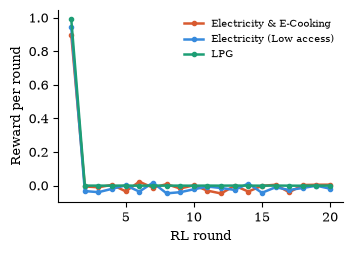

Relanzando la optimización RL (3 tecnologías) para capturar las 100 evaluaciones completas -- esto tarda varios minutos, y vas a ver el mismo progreso que en la celda 27 mientras corre.
=== RL: Electricity & E-Cooking ===

── RL Round 1/20 ──
K1=0.34, K2=0.069
Trial 0: total debt=8e+02, debt=[0, 765.7942131665932, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[339.83175384609405, 1226.0390864433514, 138.77686276991676, 158.8624797232961, 190.65025579919183, 221.86437946529722, 256.9807117032866, 296.55135397237365, 341.20236420931786, 391.64403978130883, 448.6826217177045, 519.9140905688637], lt_subsidies=[0, 66.42964316202202, 57.35746280810347, 66.52411362213897, 65.30823660535177, 63.736905685425285, 63.86870973070558, 65.77208769815833, 69.51842739200742, 75.18050200192422, 82.83051186615633, 72.9405120905434]
Trial 1: total debt=8e+02, debt=[0, 0, 0, 812.9976152223426, 0, 0, 0, 0, 0, 0, 0, 0], capex=[617.2766710523617, 161.2399007500167, 186.19198863263486, 1214.8833022640824, 296.81270288

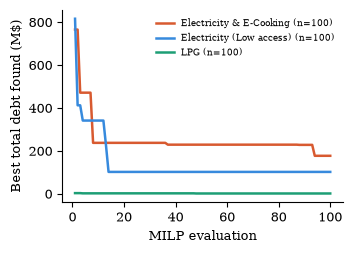

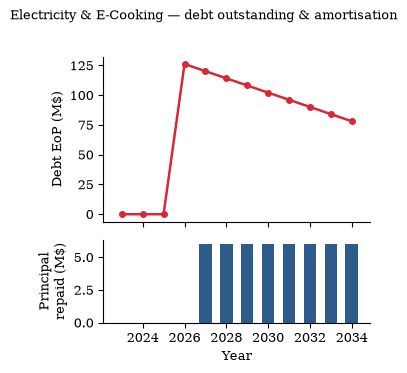

K1=0.34, K2=0.069
Trial 0: total debt=3e+02, debt=[0, 333.1616925526857, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[456.5501617045378, 763.2582840046294, 296.1907163878677, 207.28699824887016, 220.55178598873044, 248.9853973137992, 280.8993021250092, 317.52669339929315, 358.5824923629068, 404.59908807660565, 456.1343171659401, 520.4347632218112], lt_subsidies=[0, 20.505287147795816, 30.54444110601591, 43.50175821158662, 44.378689107608764, 44.22755125309577, 44.96854403946763, 46.67976870171069, 49.357802930602375, 52.989738335008155, 57.54514617055225, 43.285228204667504]
Trial 1: total debt=5e+01, debt=[0, 0, 0, 0, 47.56954946963212, 0, 0, 0, 0, 0, 0, 0], capex=[257.1623475977404, 297.4801276844481, 359.8612446272605, 388.70734731486726, 658.523447813638, 262.66141415131324, 291.4024054466691, 323.0415454786973, 357.8643120638286, 396.18411759365114, 438.345056750323, 499.76663347756386], lt_subsidies=[0, 0, 0, 0, 29.281114270514422, 25.81840865356272, 23.683213554293502, 21.6082322886276

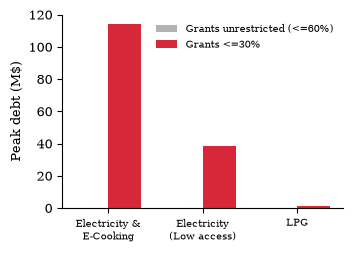

Termination: optimal


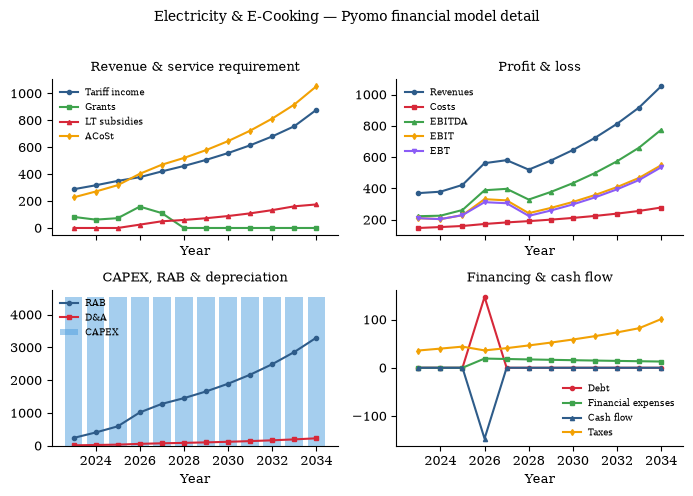

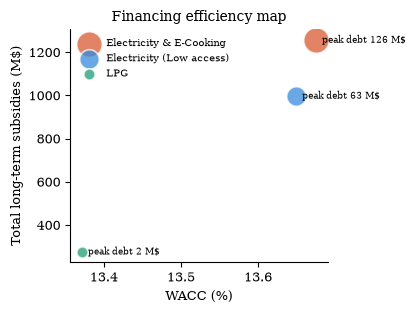

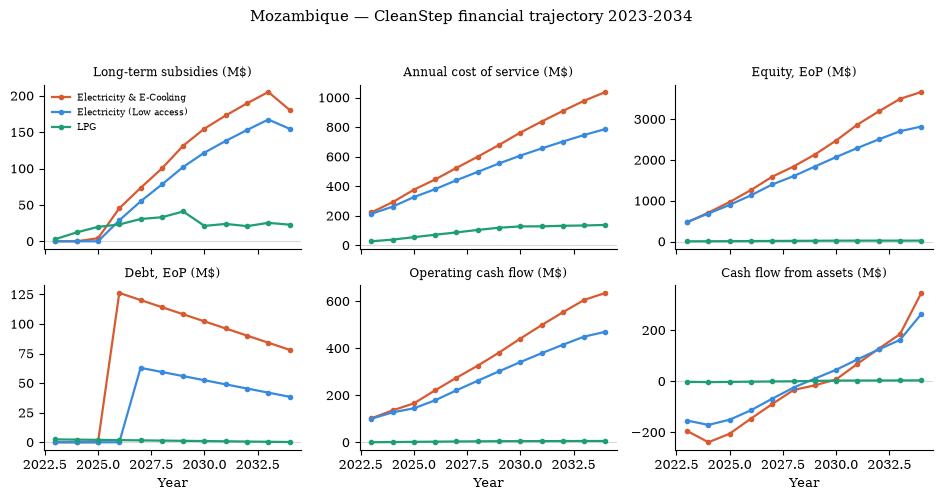

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

colors = {
    'Electricity & E-Cooking':  '#D85A30',
    'Electricity (Low access)': '#378ADD',
    'LPG':                      '#1D9E75',
}

sample_tech = next(iter(RL_HISTORIES))
sample_hist = RL_HISTORIES[sample_tech]
print(f"RL_HISTORIES['{sample_tech}']: {type(sample_hist).__name__}, "
      f"{len(sample_hist) if hasattr(sample_hist, '__len__') else '?'} elementos")
if hasattr(sample_hist, '__getitem__') and len(sample_hist):
    print("Primer elemento:", sample_hist[0])

def _get(entry, *names):
    """Busca el primer nombre de campo que exista en entry (dict o namedtuple)."""
    d = entry._asdict() if hasattr(entry, '_asdict') else entry
    if isinstance(d, dict):
        for n in names:
            if n in d:
                return d[n]
    return None

fig, ax = plt.subplots(figsize=(3.6, 2.6))
plotted_any = False

for tech, color in colors.items():
    hist = RL_HISTORIES.get(tech, [])
    series = [_get(h, 'reward', 'Reward') for h in hist]
    used = 'reward'
    if all(v is None for v in series):
        series = [_get(h, 'objective', 'Objective') for h in hist]
        used = 'objective'
    series = [v for v in series if v is not None]
    if not series:
        continue
    plotted_any = True
    ax.plot(range(1, len(series) + 1), series, '-o', color=color,
            linewidth=1.8, markersize=3, label=tech)

if not plotted_any:
    raise RuntimeError(
        "No he encontrado un campo 'reward' ni 'objective' dentro de "
        "RL_HISTORIES. Copia la línea 'Primer elemento:' de arriba y la "
        "adaptamos en un momento."
    )

ax.set_xlabel('RL round')
ax.set_ylabel(f'{used.capitalize()} per round')
ax.legend(frameon=False, fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figA_rl_convergence.pdf', bbox_inches='tight')
plt.show()

##
import re
import ast
import io
import sys
import contextlib
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

colors = {
    'Electricity & E-Cooking':  '#D85A30',
    'Electricity (Low access)': '#378ADD',
    'LPG':                      '#1D9E75',
}

class _Tee:
    """Escribe en varios streams a la vez (consola del notebook + buffer)."""
    def __init__(self, *streams):
        self.streams = streams
    def write(self, s):
        for st in self.streams:
            st.write(s)
    def flush(self):
        for st in self.streams:
            st.flush()

print("Relanzando la optimización RL (3 tecnologías) para capturar las "
      "100 evaluaciones completas -- esto tarda varios minutos, y vas a "
      "ver el mismo progreso que en la celda 27 mientras corre.")

buf = io.StringIO()
tee = _Tee(sys.stdout, buf)
with contextlib.redirect_stdout(tee):
    shared_agent, shared_optimizer, _ = load_agent()
    for tech, tech_dict in TECHNO_ELEC.items():
        print(f"=== RL: {tech} ===")
        run_rl_optimization(
            tech_dict=tech_dict, tax_rate=TAX_RATE, years=YEARS,
            initial_ranges=SEARCH_RANGES, fuel_fin=FUEL_FIN, fuel_key='Electricity',
            objective=OBJECTIVE, n_rounds=N_ROUNDS, n_trials_per_round=N_TRIALS_PER_ROUND,
            tariffs=TARIFFS, agent=shared_agent, optimizer_=shared_optimizer,
        )
    print("=== RL: LPG ===")
    run_rl_optimization(
        tech_dict={'GRID': TECHNO_LPG}, tax_rate=TAX_RATE, years=YEARS,
        initial_ranges=SEARCH_RANGES, fuel_fin=FUEL_FIN, fuel_key='LPG',
        objective=OBJECTIVE, n_rounds=N_ROUNDS, n_trials_per_round=N_TRIALS_PER_ROUND,
        tariffs=TARIFFS, agent=shared_agent, optimizer_=shared_optimizer,
    )
log = buf.getvalue()

blocks = re.split(r'=== RL: (.+?) ===', log)[1:]
trial_re = re.compile(r'Trial \d+:.*?debt=(\[[^\]]*\])')

fig, ax = plt.subplots(figsize=(3.6, 2.6))
for tech, color in colors.items():
    if tech not in blocks:
        continue
    text = blocks[blocks.index(tech) + 1]
    totals = [sum(ast.literal_eval(m)) for m in trial_re.findall(text)]
    if not totals:
        continue
    best_so_far, best = [], float('inf')
    for v in totals:
        best = min(best, v)
        best_so_far.append(best)
    ax.plot(range(1, len(best_so_far) + 1), best_so_far, '-', color=color,
            linewidth=1.8, label=f"{tech} (n={len(best_so_far)})")

ax.set_xlabel('MILP evaluation')
ax.set_ylabel('Best total debt found (M$)')
ax.legend(frameon=False, fontsize=6.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figA_search_convergence.pdf', bbox_inches='tight')
plt.show()

##
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

TECH = 'Electricity & E-Cooking'
years = YEARS

out = pio.read_outputs(TECH)
debt_eop  = out['DEBT:EoP']
repayment = [-v for v in out['DEBT:- Repayment']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.6, 3.6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(years, debt_eop, 'o-', color='#D62839', linewidth=1.8, markersize=4)
ax1.set_ylabel('Debt EoP (M$)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(years, repayment, color='#2E5C8A', width=0.6)
ax2.set_ylabel('Principal\nrepaid (M$)')
ax2.set_xlabel('Year')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(f'{TECH} — debt outstanding & amortisation', fontsize=9, y=1.02)
fig.tight_layout()
plt.savefig('figG_debt_repayment.pdf', bbox_inches='tight')
plt.show()

##
import numpy as np

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

techs_full = ['Electricity & E-Cooking', 'Electricity (Low access)', 'LPG']
techs_lbl  = ['Electricity &\nE-Cooking', 'Electricity\n(Low access)', 'LPG']

UNRESTRICTED_RANGES = dict(SEARCH_RANGES)
UNRESTRICTED_RANGES['pct_grants'] = (0.10, 0.60)

debt_unrestricted = []
for tech in techs_full:
    if tech == 'LPG':
        result = run_optimization(
            tech_dict={'GRID': TECHNO_LPG}, tax_rate=TAX_RATE, years=YEARS,
            fuel_fin=FUEL_FIN, tariffs=TARIFFS, fuel_key='LPG',
            search_ranges=UNRESTRICTED_RANGES, objective=OBJECTIVE, n_trials=N_TRIALS,
        )
    else:
        result = run_optimization(
            tech_dict=TECHNO_ELEC[tech], tax_rate=TAX_RATE, years=YEARS,
            fuel_fin=FUEL_FIN, tariffs=TARIFFS, fuel_key='Electricity',
            search_ranges=UNRESTRICTED_RANGES, objective=OBJECTIVE, n_trials=N_TRIALS,
        )
    debt_unrestricted.append(round(max(result.get('DEBT_INCREASE', [0])), 1))

debt_restricted = [
    round(max(CAPITAL_STRUCTURE[t].get('DEBT_INCREASE', [0])), 1) for t in techs_full
]

print("Deuda pico, grants sin restringir (<=60%):", dict(zip(techs_full, debt_unrestricted)))
print("Deuda pico, grants <=30% (actual):        ", dict(zip(techs_full, debt_restricted)))

x = np.arange(len(techs_full))
width = 0.35

fig, ax = plt.subplots(figsize=(3.6, 2.6))
ax.bar(x - width/2, debt_unrestricted, width, color='0.7', label='Grants unrestricted (<=60%)')
ax.bar(x + width/2, debt_restricted,  width, color='#D62839', label='Grants <=30%')

ax.set_ylabel('Peak debt (M$)')
ax.set_xticks(x)
ax.set_xticklabels(techs_lbl, fontsize=7.5)
ax.legend(frameon=False, fontsize=7.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figH_grants_sensitivity.pdf', bbox_inches='tight')
plt.show()

##

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

colors = {
    'Electricity & E-Cooking':  '#D85A30',
    'Electricity (Low access)': '#378ADD',
    'LPG':                      '#1D9E75',
}

summary = {}
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    lts      = out.get('Long term subsidies', [0] * len(YEARS))
    debt_eop = out.get('DEBT:EoP', [0] * len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next((row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'), None)
    _wb.close()

    summary[SHEET] = {
        'wacc': wacc,
        'total_lts': sum(lts),
        'peak_debt': max(abs(v) for v in debt_eop),
    }

fig, ax = plt.subplots(figsize=(4.2, 3.2))
for tech, color in colors.items():
    s = summary[tech]
    size = 60 + s['peak_debt'] * 2.2
    ax.scatter(s['wacc'], s['total_lts'], s=size, color=color, alpha=0.75,
               edgecolor='white', linewidth=1.2, zorder=3, label=tech)
    ax.annotate(f"  peak debt {s['peak_debt']:.0f} M$",
                (s['wacc'], s['total_lts']), fontsize=6.5, va='center')

ax.set_xlabel('WACC (%)')
ax.set_ylabel('Total long-term subsidies (M$)')
ax.set_title('Financing efficiency map', fontsize=10)
ax.legend(frameon=False, fontsize=7, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figI_efficiency_map.pdf', bbox_inches='tight')
plt.show()

##

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

colors = {
    'Electricity & E-Cooking':  '#D85A30',
    'Electricity (Low access)': '#378ADD',
    'LPG':                      '#1D9E75',
}

metrics = [
    ('Long term subsidies',   'Long-term subsidies (M$)'),
    ('Annual Cost of Service','Annual cost of service (M$)'),
    ('Equity - EoP',          'Equity, EoP (M$)'),
    ('DEBT:EoP',              'Debt, EoP (M$)'),
    ('Operating Cash Flow',   'Operating cash flow (M$)'),
    ('Cash Flow from Assets', 'Cash flow from assets (M$)'),
]

fig, axes = plt.subplots(2, 3, figsize=(9.5, 4.8), sharex=True)
fig.suptitle(f'{COUNTRY} — CleanStep financial trajectory {YEARS[0]}-{YEARS[-1]}',
             fontsize=11, y=1.03)

for ax, (key, title) in zip(axes.flat, metrics):
    for tech, color in colors.items():
        out = pio.read_outputs(tech)
        vals = out.get(key, [0] * len(YEARS))
        ax.plot(YEARS, vals, '-o', color=color, linewidth=1.6, markersize=3, label=tech)
    ax.set_title(title, fontsize=8.5)
    ax.axhline(0, color='0.85', linewidth=0.8, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0, 0].legend(frameon=False, fontsize=6.5, loc='upper left')
for ax in axes[1]:
    ax.set_xlabel('Year')

fig.tight_layout()
plt.savefig('figJ_financial_trajectory.pdf', bbox_inches='tight')
plt.show()

Termination: optimal


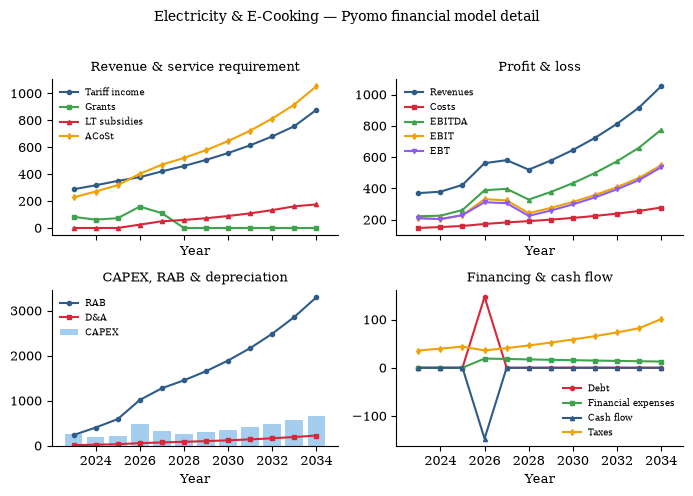

In [ ]:
import matplotlib.pyplot as plt
from pyomo.environ import value, SolverFactory
from pyomo_model import build_model, make_capex_data, make_k1_k2

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

TECH = 'Electricity & E-Cooking'
cs = RL_RESULTS[TECH]
tech_dict = TECHNO_ELEC[TECH]
n_periods = len(YEARS)

capex_total = make_capex_data(tech_dict, n_periods)
demand_base, K1, K2 = make_k1_k2(tech_dict, n_periods)

model = build_model(
    pct_debt=cs['PCT_DEBT'] / 100,
    pct_equity=cs['PCT_EQUITY'] / 100,
    pct_grants=cs['PCT_GRANTS'] / 100,
    cost_debt=cs['COST_OF_DEBT'] / 100,
    cost_equity=cs['COST_OF_EQUITY'] / 100,
    grace_period=cs['GRACE_PERIOD'],
    amortization_period=cs['AMORTIZATION'],
    years_realisation=cs['YEARS_REALISATION'],
    capex_total=capex_total,
    K1=K1, K2=K2,
    TAXRATE=TAX_RATE / 100,
    demand_base=demand_base,
    TARIFF={t: TARIFFS['Electricity'][t] if t < len(TARIFFS['Electricity']) else 0.0
            for t in range(n_periods)},
    N_PERIODS=n_periods,
)

solver = SolverFactory('appsi_highs')
result = solver.solve(model)
print("Termination:", result.solver.termination_condition)

candidate_names = ['capex_data', 'tariff_income', 'grants', 'lt_subsidies', 'acofservice',
                    'revenues', 'costs', 'ebitda', 'ebit', 'ebt',
                    'rab', 'da', 'cash_flow', 'debt',
                    'financial_expenses', 'taxes']

output_schedules = {}
for name in candidate_names:
    comp = getattr(model, name, None)
    if comp is not None:
        try:
            output_schedules[name] = [value(comp[t]) for t in model.T]
        except Exception:
            pass

years = YEARS
fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.8), sharex=True)

def safe_plot(ax, key, color, marker, label):
    if key in output_schedules:
        ax.plot(years, output_schedules[key], marker=marker, color=color, markersize=3, label=label)

safe_plot(axes[0, 0], 'tariff_income', '#2E5C8A', 'o', 'Tariff income')
safe_plot(axes[0, 0], 'grants', '#3FA34D', 's', 'Grants')
safe_plot(axes[0, 0], 'lt_subsidies', '#D62839', '^', 'LT subsidies')
safe_plot(axes[0, 0], 'acofservice', '#F2A104', 'd', 'ACoSt')
axes[0, 0].set_title('Revenue & service requirement', fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=6.5)

safe_plot(axes[0, 1], 'revenues', '#2E5C8A', 'o', 'Revenues')
safe_plot(axes[0, 1], 'costs', '#D62839', 's', 'Costs')
safe_plot(axes[0, 1], 'ebitda', '#3FA34D', '^', 'EBITDA')
safe_plot(axes[0, 1], 'ebit', '#F2A104', 'd', 'EBIT')
safe_plot(axes[0, 1], 'ebt', '#8B5CF6', 'v', 'EBT')
axes[0, 1].set_title('Profit & loss', fontsize=9)
axes[0, 1].legend(frameon=False, fontsize=6.5)

axes[1, 0].bar(years, output_schedules.get('capex_data', capex_total), alpha=0.5, color='#4C9EDF', label='CAPEX')  # <-- FIX: usa el capex_t resuelto, no el total fijo
safe_plot(axes[1, 0], 'rab', '#2E5C8A', 'o', 'RAB')
safe_plot(axes[1, 0], 'da', '#D62839', 's', 'D&A')
axes[1, 0].set_title('CAPEX, RAB & depreciation', fontsize=9)
axes[1, 0].legend(frameon=False, fontsize=6.5)

safe_plot(axes[1, 1], 'debt', '#D62839', 'o', 'Debt')
safe_plot(axes[1, 1], 'financial_expenses', '#3FA34D', 's', 'Financial expenses')
safe_plot(axes[1, 1], 'cash_flow', '#2E5C8A', '^', 'Cash flow')
safe_plot(axes[1, 1], 'taxes', '#F2A104', 'd', 'Taxes')
axes[1, 1].set_title('Financing & cash flow', fontsize=9)
axes[1, 1].legend(frameon=False, fontsize=6.5)

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'{TECH} — Pyomo financial model detail', fontsize=10, y=1.02)
fig.tight_layout()
plt.savefig('figC_financial_panel.pdf', bbox_inches='tight')
plt.show()